In [7]:
import pandas as pd
import os

print(os.getcwd())
print(os.listdir())
df = pd.read_csv("data/Disaster_dataset.csv",sep =";")
print("\n===============================")
print("# Online Retail Customer Segmentation Dataset")
print("===============================")
print(df.head())
print(df.info())
print(df.isnull().sum())


c:\Users\shreya\Desktop\DVT_Lab
['.git', 'data', 'dvt_01.ipynb']

# Online Retail Customer Segmentation Dataset
   Year     Country  ISO Disaster Group Disaster Subroup      Disaster Type  \
0  1900  Cabo Verde  CPV        Natural   Climatological            Drought   
1  1900       India  IND        Natural   Climatological            Drought   
2  1900     Jamaica  JAM        Natural     Hydrological              Flood   
3  1900       Japan  JPN        Natural      Geophysical  Volcanic activity   
4  1900      Turkey  TUR        Natural      Geophysical         Earthquake   

  Disaster Subtype  Total Events  Total Affected  Total Deaths  \
0          Drought             1             NaN       11000.0   
1          Drought             1             NaN     1250000.0   
2              NaN             1             NaN         300.0   
3         Ash fall             1             NaN          30.0   
4  Ground movement             1             NaN         140.0   

   Total Damage 

In [9]:
%pip install pandas numpy matplotlib seaborn plotly

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 2.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.3 MB 3.0 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 3.1 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 3.1 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 3.0 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.3 MB 2.8 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 2.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.3 MB 2.6 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [14]:
df.isnull().sum()


Year                               0
Country                            0
ISO                                0
Disaster Group                     0
Disaster Subroup                   0
Disaster Type                      0
Disaster Subtype                2133
Total Events                       0
Total Affected                  2845
Total Deaths                    3056
Total Damage (USD, original)    6597
Total Damage (USD, adjusted)    6601
CPI                               51
dtype: int64

In [21]:
df['Total Affected']= df['Total Affected'].fillna(0)
df["Total Deaths"] = df["Total Deaths"].fillna(0)
df["Total Damage (USD, original)"] = df["Total Damage (USD, original)"].fillna(0)
df["Total Damage (USD, adjusted)"] = df["Total Damage (USD, adjusted)"].fillna(0)


In [23]:
df["CPI"] = df["CPI"].fillna(df["CPI"].median())
df["Disaster Subtype"] = df["Disaster Subtype"].fillna("Unknown")

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10431 entries, 0 to 10430
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          10431 non-null  int64  
 1   Country                       10431 non-null  str    
 2   ISO                           10431 non-null  str    
 3   Disaster Group                10431 non-null  str    
 4   Disaster Subroup              10431 non-null  str    
 5   Disaster Type                 10431 non-null  str    
 6   Disaster Subtype              10431 non-null  str    
 7   Total Events                  10431 non-null  int64  
 8   Total Affected                10431 non-null  float64
 9   Total Deaths                  10431 non-null  float64
 10  Total Damage (USD, original)  10431 non-null  float64
 11  Total Damage (USD, adjusted)  10431 non-null  float64
 12  CPI                           10431 non-null  float64
dtypes: float64(5

In [25]:
df.columns

Index(['Year', 'Country', 'ISO', 'Disaster Group', 'Disaster Subroup',
       'Disaster Type', 'Disaster Subtype', 'Total Events', 'Total Affected',
       'Total Deaths', 'Total Damage (USD, original)',
       'Total Damage (USD, adjusted)', 'CPI'],
      dtype='str')

In [26]:
df.rename(columns={
    "Disaster Type":"DisasterType",
    "Total Deaths":"Deaths",
    "Total Affected":"Affected",
    "Total Damage (USD, original)":"DamageOriginal",
    "Total Damage (USD, adjusted)":"DamageAdjusted"
    
}, inplace=True)

In [28]:
df["Year"] = df["Year"].astype(int)
df.describe()

,Year,Total Events,Affected,Deaths,DamageOriginal,DamageAdjusted,CPI
count,10431.000000,10431.000000,1.043100e+04,1.043100e+04,1.043100e+04,1.043100e+04,10431.0
mean,1995.609625,1.446649,8.188671e+05,2.197236e+03,4.124968e+08,6.420800e+08,100.0
std,22.001186,1.246589,8.338960e+06,6.102373e+04,4.153026e+09,5.586928e+09,0.0
min,1900.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,100.0
25%,1986.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,100.0
50%,2001.000000,1.000000,2.202000e+03,9.000000e+00,0.000000e+00,0.000000e+00,100.0
75%,2011.000000,1.000000,4.508300e+04,5.000000e+01,1.900000e+07,3.842655e+07,100.0
max,2023.000000,20.000000,3.300000e+08,3.700000e+06,2.100000e+11,2.732184e+11,100.0


In [32]:
df["DisasterType"].value_counts()



DisasterType
Flood                    3837
Storm                    2761
Earthquake               1087
Drought                   784
Landslide                 652
Extreme temperature       565
Wildfire                  374
Volcanic activity         231
Insect infestation         92
Mass movement (dry)        44
Glacial lake outburst       2
Fog                         1
Animal accident             1
Name: count, dtype: int64

In [34]:
df["Country"].value_counts().head(10)


Country
United States of America (the)    405
China                             385
India                             362
Indonesia                         274
Philippines (the)                 271
Japan                             258
Bangladesh                        231
Mexico                            195
Pakistan                          175
Peru                              156
Name: count, dtype: int64

In [35]:
#TOP 10 countries with the highest number of deaths
df.groupby("DisasterType")[ "Deaths"].sum()

DisasterType
Animal accident                12.0
Drought                  11734025.0
Earthquake                2398559.0
Extreme temperature        210711.0
Flood                     7003859.0
Fog                          4000.0
Glacial lake outburst         261.0
Insect infestation              0.0
Landslide                   67919.0
Mass movement (dry)          4486.0
Storm                     1403966.0
Volcanic activity           86912.0
Wildfire                     4656.0
Name: Deaths, dtype: float64

In [38]:
#Total Economic Damage by Disaster Type
df.groupby("Country")["DamageOriginal ('000 US$)"].sum()

KeyError: "Column not found: DamageOriginal ('000 US$)"

In [40]:
df.groupby("Country")["DamageOriginal"].sum()

Country
Afghanistan        6.033200e+08
Albania            8.273730e+08
Algeria            1.181485e+10
American Samoa     2.050000e+08
Angola             1.200000e+07
                       ...     
Yemen Arab Rep     2.022700e+09
Yemen P Dem Rep    1.040200e+09
Yugoslavia         3.939800e+09
Zambia             2.090000e+07
Zimbabwe           1.037700e+09
Name: DamageOriginal, Length: 225, dtype: float64

C:\Users\shreya\AppData\Local\Temp\ipykernel_24920\1099992514.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


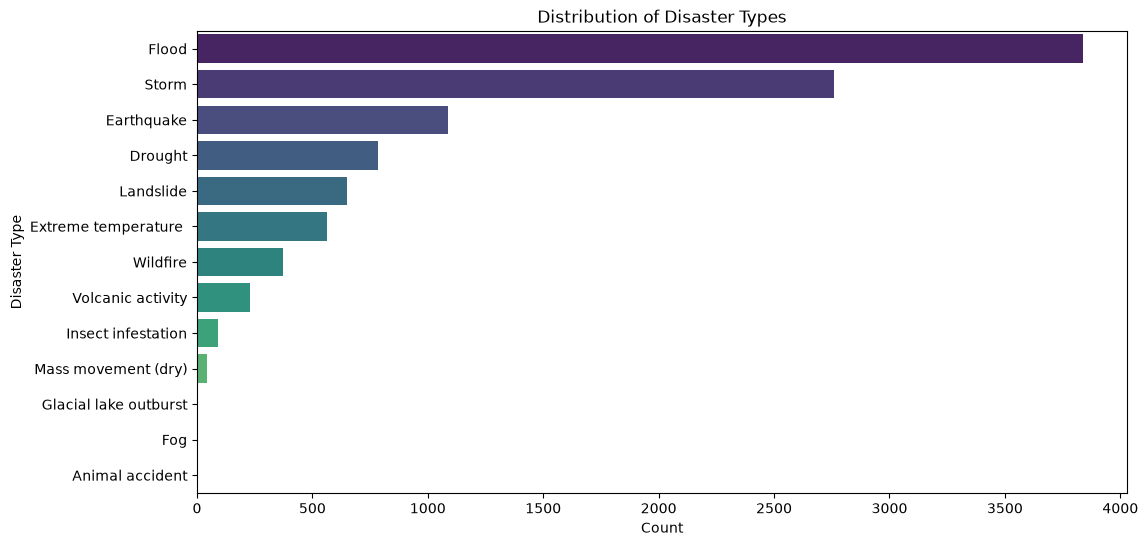

In [41]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="DisasterType",
    order=df["DisasterType"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Disaster Types")
plt.xlabel("Count")
plt.ylabel("Disaster Type")

plt.show()

C:\Users\shreya\AppData\Local\Temp\ipykernel_24920\1006213554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


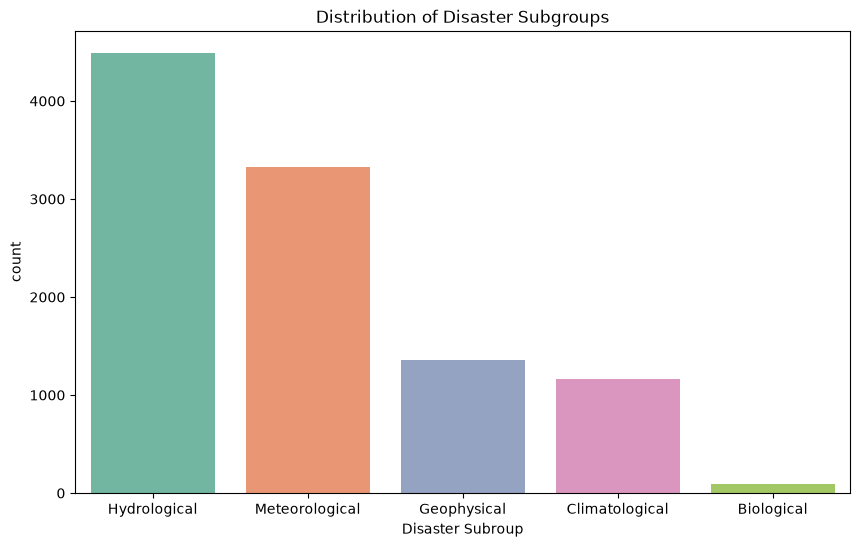

In [49]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Disaster Subroup",
    order=df["Disaster Subroup"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of Disaster Subgroups")

plt.show()

In [45]:
print(df.columns)

Index(['Year', 'Country', 'ISO', 'Disaster Group', 'Disaster Subroup',
       'DisasterType', 'Disaster Subtype', 'Total Events', 'Affected',
       'Deaths', 'DamageOriginal', 'DamageAdjusted', 'CPI'],
      dtype='str')


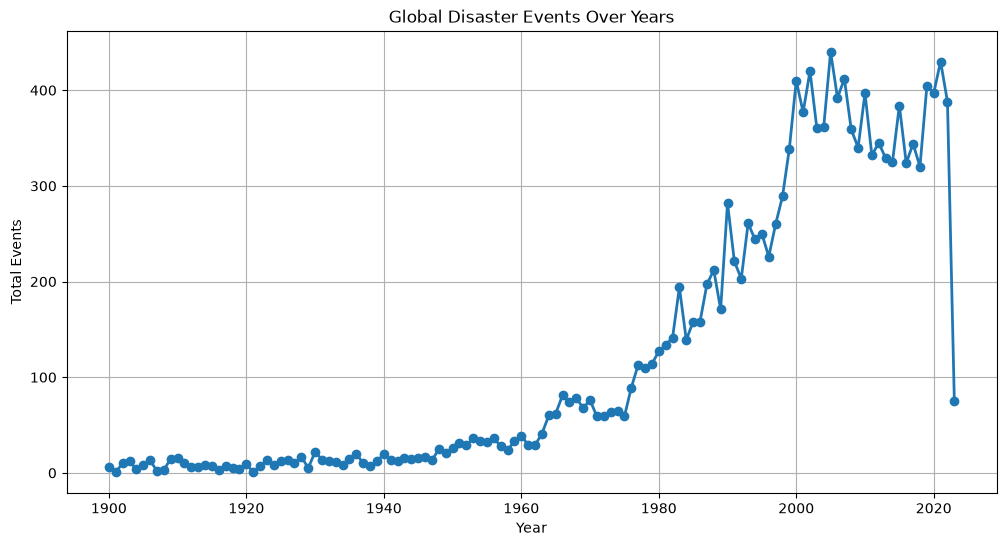

In [50]:
yearly = df.groupby("Year")["Total Events"].sum()

plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o",
    linewidth=2
)

plt.title("Global Disaster Events Over Years")
plt.xlabel("Year")
plt.ylabel("Total Events")
plt.grid(True)

plt.show()

C:\Users\shreya\AppData\Local\Temp\ipykernel_24920\645931367.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


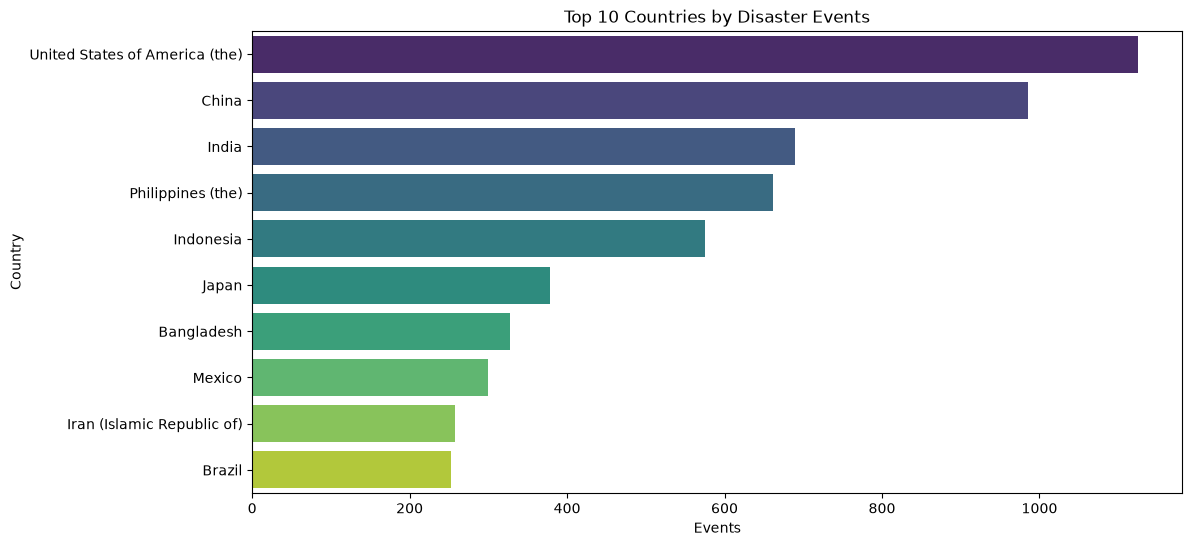

In [51]:
top = df.groupby("Country")["Total Events"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top.values,
    y=top.index,
    palette="viridis"
)

plt.title("Top 10 Countries by Disaster Events")
plt.xlabel("Events")
plt.ylabel("Country")

plt.show()

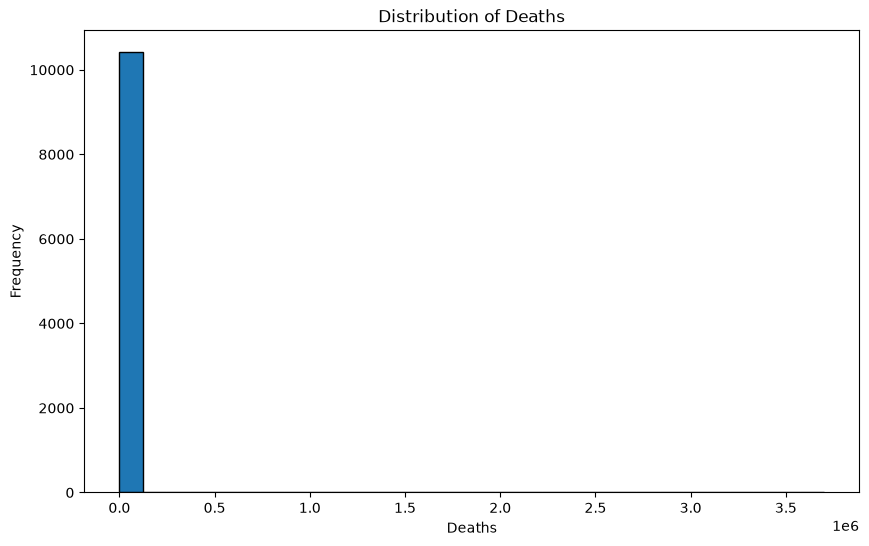

In [52]:
#Histogram (Deaths Distribution)
plt.figure(figsize=(10,6))

plt.hist(
    df["Deaths"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Deaths")
plt.xlabel("Deaths")
plt.ylabel("Frequency")

plt.show()

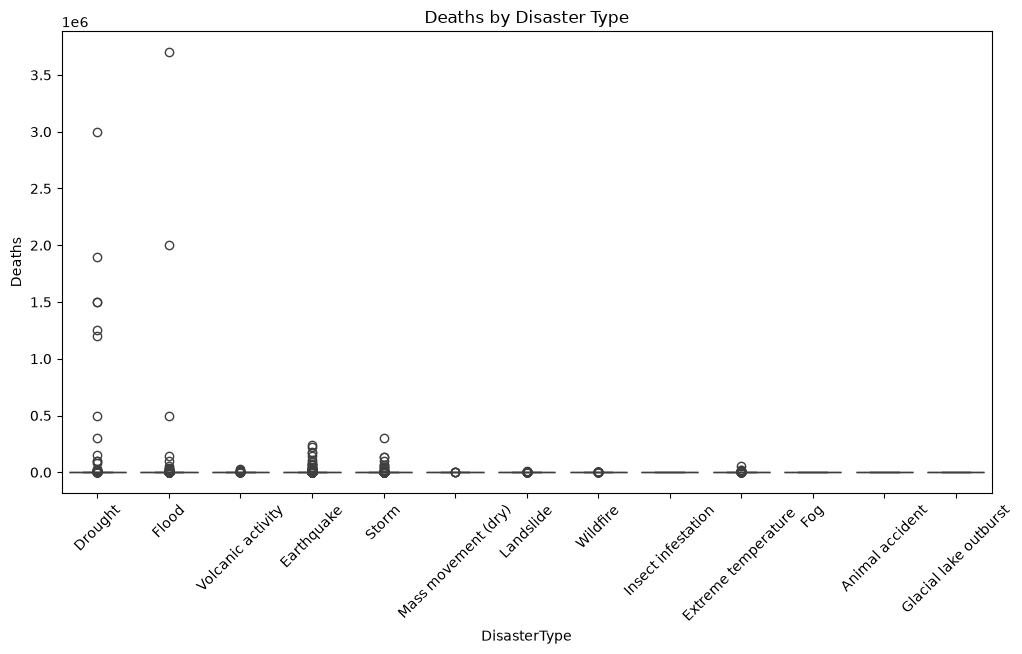

In [53]:
#Box plot (Deaths Distribution)
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="DisasterType",
    y="Deaths"
)

plt.xticks(rotation=45)

plt.title("Deaths by Disaster Type")

plt.show()

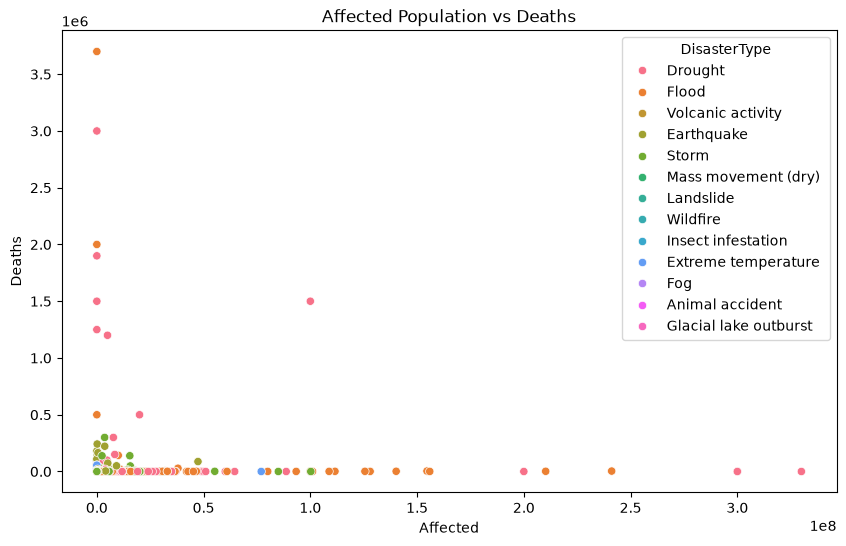

In [54]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Affected",
    y="Deaths",
    hue="DisasterType"
)

plt.title("Affected Population vs Deaths")

plt.show()

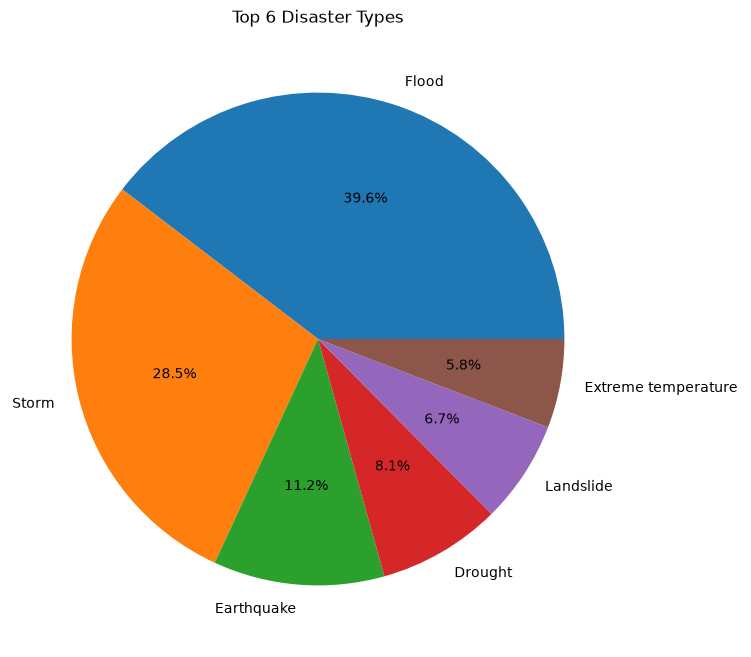

In [55]:
plt.figure(figsize=(8,8))

df["DisasterType"].value_counts().head(6).plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Top 6 Disaster Types")

plt.show()

C:\Users\shreya\AppData\Local\Temp\ipykernel_24920\2749504797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


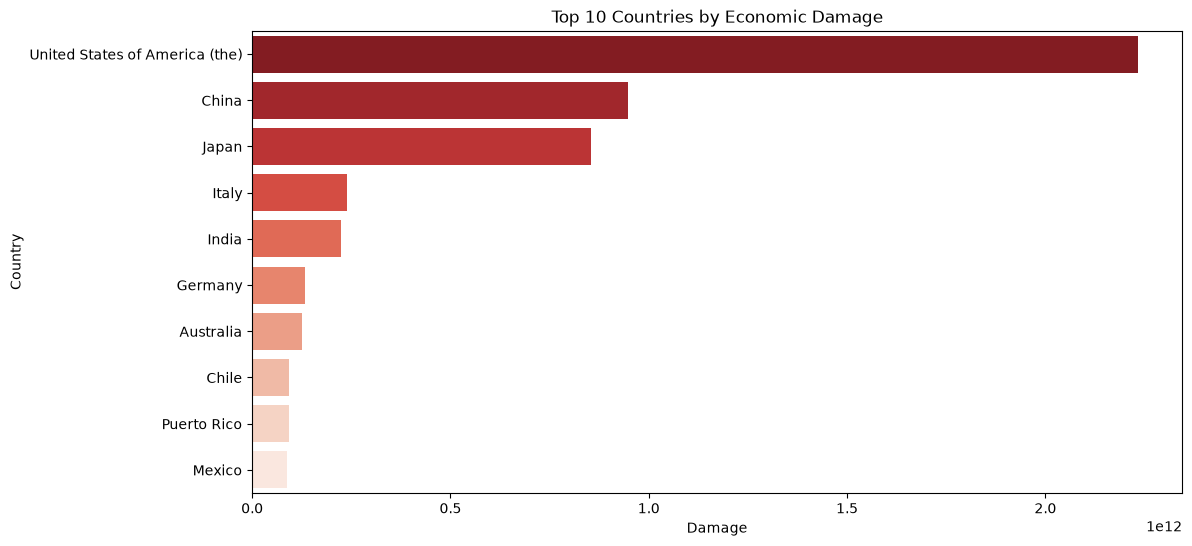

In [56]:
#Top 10 countries by economic damage
damage = df.groupby("Country")["DamageAdjusted"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=damage.values,
    y=damage.index,
    palette="Reds_r"
)

plt.title("Top 10 Countries by Economic Damage")
plt.xlabel("Damage")
plt.ylabel("Country")

plt.show()